mypy: disable-error-code="import-untyped,no-redef,misc"

In [1]:
"""Notebook source for comparing the retained Egglog baseline to archived and live Haskell artifacts."""

'Notebook source for comparing the retained Egglog baseline to archived and live Haskell artifacts.'

# 2026-03 - Replicating the Param-Eq Paper in Egglog

This notebook rebuilds the de Franca and Kronberger (2023) paper figures from
the archived Haskell experiment outputs, then compares the current Egglog
baseline primarily against a fresh full-corpus artifact generated from the
current local `param-eq-haskell` code.

The Haskell sources this notebook is tracing back to are:
- `../param-eq-haskell/src/FixTree.hs`
- `../param-eq-haskell/src/Main.hs`

It is artifacts-first:
- it reads normalized archived Haskell artifacts from `python/egglog/exp/param_eq/artifacts`
- it reads a fresh full-corpus live Haskell artifact from the same directory
- it reads the Egglog corpus results from the same directory
- it does not run Haskell at notebook execution time

Offline regeneration commands from the repository root:
- `uv run python -m egglog.exp.param_eq.normalize_archives`
- `uv run python -m egglog.exp.param_eq.run_haskell_corpus`
- `uv run python -m egglog.exp.param_eq.run_egglog_corpus`
- `uv run python python/egglog/exp/param_eq/replication.py`

The executed `.ipynb` shown in GitHub is generated from this `py:light` file.

In [2]:
from __future__ import annotations

import os
from io import StringIO

import altair as alt
import pandas as pd
from IPython.display import Markdown, SVG, display
from nbclient import NotebookClient
import nbformat
import jupytext
from egglog.exp.param_eq.paths import ARTIFACT_DIR, PARAM_EQ_DIR


alt.data_transformers.disable_max_rows()
alt.renderers.enable("default")

ALGORITHM_ORDER = ["Bingo", "EPLEX", "GP-GOMEA", "Operon", "PySR", "SBP"]
MODE_LABELS = {
    "egglog-baseline": "Egglog baseline",
    "no-haskell-backoff": "No Haskell backoff",
    "no-graph-size-stop": "No graph-size stop",
    "no-bound-scheduler": "No bound scheduler",
    "no-fresh-rematch": "No fresh rematch",
    "egglog-haskell-literal": "Historical literal alias",
}
BOX_COLOR = "#4C78A8"
POINT_COLOR = "#F58518"
MISMATCH_COLOR = "#E45756"
ARCHIVED_HASKELL_PATH = ARTIFACT_DIR / "haskell_paper_rows.csv"
LIVE_HASKELL_PATH = ARTIFACT_DIR / "haskell_live_rows.csv"
EGGLOG_PATH = ARTIFACT_DIR / "egglog_paper_rows.csv"
EGGLOG_ABLATION_PATH = ARTIFACT_DIR / "egglog_ablation_rows.csv"
ABLATION_SUMMARY_PATH = ARTIFACT_DIR / "ablation_summary.csv"
RUNTIME_PATH = ARTIFACT_DIR / "pagie_runtime_scatter.csv"

for required_path in [ARCHIVED_HASKELL_PATH, LIVE_HASKELL_PATH, EGGLOG_PATH, RUNTIME_PATH]:
    if not required_path.exists():
        msg = f"Missing required artifact: {required_path}"
        raise FileNotFoundError(msg)


def _coerce_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def _paper_haskell_frame() -> pd.DataFrame:
    frame = pd.read_csv(ARCHIVED_HASKELL_PATH)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "n_params",
            "n_rank",
        ],
    )


def _live_haskell_frame() -> pd.DataFrame:
    frame = pd.read_csv(LIVE_HASKELL_PATH)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_runtime_ms",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "sympy_runtime_ms",
            "n_params",
            "n_rank",
        ],
    )


def _paper_egglog_frame(path: os.PathLike[str] | str = EGGLOG_PATH) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame = frame[frame["is_paper_row"] == 1].copy()
    return _coerce_numeric(
        frame,
        [
            "raw_index",
            "algo_row",
            "n_params",
            "n_rank",
            "orig_runtime_ms",
            "orig_nodes",
            "orig_params",
            "simpl_nodes",
            "simpl_params",
            "orig_total_size",
            "orig_egraph_nodes",
            "orig_eclass_count",
            "orig_passes",
            "orig_extracted_cost",
            "sympy_runtime_ms",
            "orig_nodes_sympy",
            "orig_params_sympy",
            "simpl_nodes_sympy",
            "simpl_params_sympy",
            "sympy_total_size",
            "sympy_egraph_nodes",
            "sympy_eclass_count",
            "sympy_passes",
            "sympy_extracted_cost",
        ],
    )


def _ablation_summary_frame() -> pd.DataFrame:
    if ABLATION_SUMMARY_PATH.exists():
        frame = pd.read_csv(ABLATION_SUMMARY_PATH)
        frame = _coerce_numeric(frame, ["orig_max_gap", "sympy_max_gap", "orig_median_delta", "sympy_median_delta"])
        for column in ["orig_pattern_ok", "sympy_pattern_ok", "accepted"]:
            if column in frame.columns:
                frame[column] = frame[column].map(
                    lambda value: value
                    if isinstance(value, bool)
                    else str(value).strip().lower() in {"1", "true", "yes", "pass"}
                )
        return frame
    return pd.DataFrame()


def _paper_runtime_frame() -> pd.DataFrame:
    frame = pd.read_csv(RUNTIME_PATH)
    return _coerce_numeric(frame, ["node_count", "runtime_ms"])


def add_paper_metrics(frame: pd.DataFrame, *, prefix: str) -> pd.DataFrame:
    result = frame.copy()
    result["orig_x_egg"] = (result[prefix + "orig_params"] - result[prefix + "simpl_params"]) / result[
        prefix + "orig_params"
    ]
    result["orig_x_sympy"] = (result[prefix + "orig_params"] - result[prefix + "orig_params_sympy"]) / result[
        prefix + "orig_params"
    ]
    result["orig_x_sympyegg"] = (result[prefix + "orig_params"] - result[prefix + "simpl_params_sympy"]) / result[
        prefix + "orig_params"
    ]
    result["sympy_x_egg"] = (result[prefix + "orig_params_sympy"] - result[prefix + "simpl_params"]) / result[
        prefix + "orig_params_sympy"
    ]
    result["sympyegg_x_egg"] = (result[prefix + "simpl_params_sympy"] - result[prefix + "simpl_params"]) / result[
        prefix + "simpl_params_sympy"
    ]
    result["orig_rank"] = result["n_params"] - result["n_rank"]
    result["simpl_rank"] = result[prefix + "simpl_params"] - result["n_rank"]
    result["sympy_rank"] = result[prefix + "orig_params_sympy"] - result["n_rank"]
    return result


def melt_methods(frame: pd.DataFrame, *, columns: dict[str, str], value_name: str) -> pd.DataFrame:
    melted = frame.melt(
        id_vars=["dataset", "algorithm", "raw_index"],
        value_vars=list(columns.values()),
        var_name="method_key",
        value_name=value_name,
    )
    inverse = {value: key for key, value in columns.items()}
    melted["method"] = melted["method_key"].map(inverse)
    return melted.drop(columns=["method_key"])


def _point_layer(frame: pd.DataFrame, *, tooltip: list[str]) -> alt.Chart:
    return (
        alt.Chart(frame)
        .transform_calculate(jitter="(random() - 0.5) * 18")
        .mark_circle(size=46, color=POINT_COLOR, opacity=0.72, stroke="white", strokeWidth=0.8)
        .encode(xOffset=alt.XOffset("jitter:Q"), tooltip=tooltip)
    )


def boxplot_chart(frame: pd.DataFrame, *, y: str, title: str) -> alt.Chart:
    base = (
        alt.Chart(frame)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y(f"{y}:Q", title=y.replace("_", " ")),
        )
        .properties(width=120, height=280)
    )
    return (
        alt.layer(
            base.mark_boxplot(size=18, opacity=0.6, color=BOX_COLOR, outliers=False),
            _point_layer(
                frame,
                tooltip=["dataset", "algorithm", "method", "raw_index", y],
            ).encode(
                x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
                y=alt.Y(f"{y}:Q", title=y.replace("_", " ")),
            ),
        )
        .facet(column=alt.Column("method:N", title=None))
        .properties(title=title)
        .resolve_scale(y="shared")
    )


def rank_boxplot(frame: pd.DataFrame, *, title: str) -> alt.Chart:
    base = (
        alt.Chart(frame)
        .encode(
            x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
            y=alt.Y("simpl_rank:Q", title="simplified params - rank"),
        )
        .properties(width=180, height=280)
    )
    return (
        alt.layer(
            base.mark_boxplot(size=18, opacity=0.6, color=BOX_COLOR, outliers=False),
            _point_layer(
                frame,
                tooltip=["dataset", "algorithm", "raw_index", "simpl_rank", "n_rank", "simpl_params"],
            ).encode(
                x=alt.X("algorithm:N", sort=ALGORITHM_ORDER, title="Algorithm"),
                y=alt.Y("simpl_rank:Q", title="simplified params - rank"),
            ),
        )
        .facet(column=alt.Column("dataset:N", title=None))
        .properties(title=title)
        .resolve_scale(y="shared")
    )


def comparison_table(frame: pd.DataFrame, *, implementation: str) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for dataset in ["pagie", "kotanchek"]:
        dataset_frame = frame[frame["dataset"] == dataset]
        for algorithm in ALGORITHM_ORDER:
            algo_frame = dataset_frame[dataset_frame["algorithm"] == algorithm]
            for delta in [0, 1]:
                eligible = algo_frame[algo_frame["orig_rank"] > delta]
                percent = float("nan")
                if not eligible.empty:
                    percent = 100.0 * (eligible["simpl_rank"] <= delta).sum() / len(eligible)
                rows.append({
                    "implementation": implementation,
                    "dataset": dataset,
                    "algorithm": algorithm,
                    "delta": f"Δ {'==' if delta == 0 else '<='} {delta}",
                    "percent": percent,
                })
    return pd.DataFrame(rows)


def table4_wide(frame: pd.DataFrame, index_columns: list[str]) -> pd.DataFrame:
    zero = frame[frame["delta"] == "Δ == 0"][[*index_columns, "percent"]].rename(columns={"percent": "Δ == 0"})
    one = frame[frame["delta"] == "Δ <= 1"][[*index_columns, "percent"]].rename(columns={"percent": "Δ <= 1"})
    return zero.merge(one, on=index_columns, how="outer")


def runtime_scatter(frame: pd.DataFrame, *, x: str, y: str, color: str, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_circle(size=72, opacity=0.78, stroke="white", strokeWidth=0.8)
        .encode(
            x=alt.X(f"{x}:Q"),
            y=alt.Y(f"{y}:Q"),
            color=alt.Color(f"{color}:N"),
            tooltip=list(frame.columns),
        )
        .properties(title=title, width=360, height=300)
    )


def status_summary_chart(frame: pd.DataFrame, *, title: str) -> alt.Chart:
    return (
        alt.Chart(frame)
        .mark_bar()
        .encode(
            x=alt.X("count:Q", title="rows"),
            y=alt.Y("status:N", sort="-x", title=None),
            color=alt.Color("status:N", legend=None),
            column=alt.Column("mode:N", title=None),
        )
        .properties(title=title, width=180, height=180)
    )


def show_chart(chart: alt.Chart) -> None:
    buffer = StringIO()
    chart.save(buffer, format="svg")
    display(SVG(buffer.getvalue()))


def show_note(text: str) -> None:
    display(Markdown(f"**What this shows:** {text}"))


def _share_phrase(numerator: int, denominator: int) -> str:
    if denominator == 0:
        return "none"
    share = numerator / denominator
    if share >= 0.95:
        return "nearly all"
    if share >= 0.8:
        return "most"
    if share >= 0.65:
        return "a clear majority of"
    if share >= 0.45:
        return "about half of"
    if share >= 0.2:
        return "a minority of"
    return "very few"


def summarize_haskell_reduction_ratios(frame: pd.DataFrame, *, context: str) -> str:
    medians = frame.groupby("method")["ratio"].median()
    eqsat = medians.get("EqSat", 0.0)
    sympy = medians.get("Sympy", 0.0)
    combined = medians.get("Sympy + EqSat", 0.0)
    if eqsat > 0 and combined >= 0 and sympy <= 0:
        return (
            f"For {context}, this is the target paper-era pattern: EqSat is helpful on its own, "
            "Sympy alone is weaker or can regress, and the combined pipeline recovers much of that gap. "
            "A faithful Egglog baseline should preserve that separation between the three modes."
        )
    if eqsat > 0 and combined > 0 and sympy <= combined:
        return (
            f"For {context}, this is the target qualitative ordering: EqSat and the combined pipeline both reduce parameters, "
            "while Sympy alone is not the main source of the gain. The Egglog baseline should look similar if it is reproducing the paper behavior."
        )
    return (
        f"For {context}, this chart defines the baseline shape the Egglog reproduction is aiming at: "
        "the three modes should not collapse onto the same distribution if the pipeline stages are being reproduced distinctly."
    )


def summarize_haskell_comparison_ratios(frame: pd.DataFrame, *, context: str) -> str:
    medians = frame.groupby("method")["ratio"].median()
    sympy_vs_eqsat = medians.get("Sympy x EqSat", 0.0)
    combined_vs_eqsat = medians.get("Sympy + EqSat x EqSat", 0.0)
    if sympy_vs_eqsat > 0 and combined_vs_eqsat <= sympy_vs_eqsat:
        return (
            f"For {context}, the archived baseline says EqSat is doing real extra work beyond Sympy preprocessing alone. "
            "That means a faithful Egglog reproduction should still show a visible advantage for rerunning EqSat after the symbolic preprocessing stage."
        )
    return (
        f"For {context}, this chart sets the baseline expectation for how much EqSat should add beyond the Sympy-derived starting point."
    )


def summarize_rank_target(frame: pd.DataFrame, *, context: str) -> str:
    near_rank = int((frame["simpl_rank"] <= 1).sum())
    total = len(frame)
    return (
        f"For {context}, the archived baseline usually lands at or very near the target rank. "
        f"So the reproduction target here is not just qualitative simplification, but getting { _share_phrase(near_rank, total) } rows down to the rank target or within one."
    )


def summarize_runtime_baseline(frame: pd.DataFrame, *, x: str, y: str, context: str) -> str:
    clean = frame[[x, y]].dropna()
    correlation = clean[x].corr(clean[y]) if len(clean) > 1 else 0.0
    if correlation > 0.5:
        return (
            f"For {context}, the runtime tail clearly grows with expression size. "
            "This is the baseline difficulty pattern Egglog should match qualitatively even if exact runtimes differ."
        )
    return (
        f"For {context}, this chart is mainly a baseline reference for where the hard cases live; larger inputs should dominate the tail."
    )


def summarize_egglog_reduction_vs_haskell(candidate: pd.DataFrame, baseline: pd.DataFrame, *, context: str) -> str:
    candidate_medians = candidate.groupby("method")["ratio"].median()
    baseline_medians = baseline.groupby("method")["ratio"].median()
    candidate_spread = candidate_medians.max() - candidate_medians.min()
    baseline_spread = baseline_medians.max() - baseline_medians.min()
    if candidate_spread < baseline_spread * 0.5:
        return (
            f"For {context}, Egglog does not preserve the method separation visible in the Haskell reference artifact. "
            "The three modes collapse toward the same reduction level, which argues that Egglog is not yet reproducing the distinct effect of each pipeline stage."
        )
    return (
        f"For {context}, Egglog broadly preserves the same qualitative ordering as the Haskell reference artifact, "
        "which supports the hypothesis that the reproduction is close on this slice."
    )


def summarize_egglog_comparison_vs_haskell(candidate: pd.DataFrame, baseline: pd.DataFrame, *, context: str) -> str:
    candidate_medians = candidate.groupby("method")["ratio"].median()
    baseline_medians = baseline.groupby("method")["ratio"].median()
    if candidate_medians.get("Sympy x EqSat", 0.0) < baseline_medians.get("Sympy x EqSat", 0.0) * 0.5:
        return (
            f"For {context}, Egglog largely loses the extra gain that the Haskell reference artifact gets from rerunning EqSat after Sympy. "
            "That supports the current hypothesis that the remaining gap is in how Egglog reproduces the rewrite schedule and A/C-heavy search, not in the basic parser or metric bookkeeping."
        )
    return (
        f"For {context}, Egglog retains most of the Haskell-reference advantage of EqSat over the Sympy-derived inputs, "
        "which supports the baseline-reproduction hypothesis for this comparison."
    )


def summarize_egglog_rank_vs_haskell(candidate: pd.DataFrame, baseline: pd.DataFrame, *, context: str) -> str:
    candidate_near = (candidate["simpl_rank"] <= 1).sum()
    baseline_near = (baseline["simpl_rank"] <= 1).sum()
    if candidate_near >= baseline_near * 0.9:
        return (
            f"For {context}, Egglog is close to the Haskell reference on the coarse rank target. "
            "So the remaining mismatch is not that Egglog fails to simplify at all; it is that it still misses some of the exact final forms and some hard cases."
        )
    return (
        f"For {context}, Egglog is still noticeably behind the Haskell reference even on the coarse rank target, "
        "so the reproduction gap is visible before we look at exact expression equality."
    )


def summarize_egglog_runtime(frame: pd.DataFrame, *, x: str, y: str, context: str) -> str:
    clean = frame[[x, y]].dropna()
    correlation = clean[x].corr(clean[y]) if len(clean) > 1 else 0.0
    if correlation > 0.5:
        return (
            f"For {context}, Egglog shows the same basic size-driven runtime tail as the Haskell reference. "
            "That supports the idea that it is hitting the same families of hard expressions, even though some outcomes still diverge."
        )
    return (
        f"For {context}, runtime does not track size as strongly as in the Haskell reference, "
        "which would suggest a different failure mode."
    )


def summarize_match_scatter(frame: pd.DataFrame, *, context: str) -> str:
    total = len(frame)
    exact = int(frame["orig_param_match"].sum())
    phrase = _share_phrase(exact, total)
    if exact / total >= 0.8:
        return (
            f"For {context}, {phrase} sit on or very near the diagonal. "
            "That supports the hypothesis that Egglog is partially reproducing the Haskell reference on final parameter counts, but not yet meeting it exactly across the whole corpus."
        )
    return (
        f"For {context}, too many points miss the diagonal for us to call the baseline reproduced yet."
    )


def summarize_status_counts(frame: pd.DataFrame, *, context: str) -> str:
    counts = frame.groupby("status")["count"].sum()
    saturated = int(counts.get("saturated", 0))
    total = int(counts.sum())
    phrase = _share_phrase(saturated, total)
    return (
        f"For {context}, {phrase} finish in the normal saturated path. "
        "That means the current baseline is usable for comparison work, but the remaining unsaturated tail is still large enough to matter for paper-faithful reproduction."
    )


def _mode_label(mode: str) -> str:
    return MODE_LABELS.get(mode, mode)


def _per_algorithm_median_deltas(frame: pd.DataFrame, simpl_col: str) -> dict[str, float]:
    deltas = frame.assign(delta=frame[simpl_col] - frame["n_params"]).groupby("algorithm")["delta"].median()
    return {algorithm: float(deltas.get(algorithm, float("nan"))) for algorithm in ALGORITHM_ORDER}


def _same_pattern(observed: dict[str, float], expected: dict[str, float]) -> bool:
    return all(observed.get(algorithm) == expected.get(algorithm) for algorithm in ALGORITHM_ORDER)


def ablation_summary_table(candidate_rows: pd.DataFrame, live_rows: pd.DataFrame) -> pd.DataFrame:
    if candidate_rows.empty:
        return pd.DataFrame()
    live_orig_pattern = _per_algorithm_median_deltas(live_rows, "simpl_params")
    live_sympy_pattern = _per_algorithm_median_deltas(live_rows, "simpl_params_sympy")
    rows: list[dict[str, object]] = []
    for mode, frame in candidate_rows.groupby("mode"):
        compare = frame.merge(
            live_rows[
                [
                    "dataset",
                    "raw_index",
                    "algorithm",
                    "simpl_params",
                    "simpl_params_sympy",
                ]
            ],
            on=["dataset", "raw_index", "algorithm"],
            suffixes=("_egglog", "_haskell"),
        )
        orig_exact = int((compare["simpl_params_egglog"] == compare["simpl_params_haskell"]).sum())
        sympy_exact = int((compare["simpl_params_sympy_egglog"] == compare["simpl_params_sympy_haskell"]).sum())
        orig_gap = int((compare["simpl_params_egglog"] - compare["simpl_params_haskell"]).abs().max())
        sympy_gap = int((compare["simpl_params_sympy_egglog"] - compare["simpl_params_sympy_haskell"]).abs().max())
        orig_median_delta = float((frame["simpl_params"] - frame["n_params"]).median())
        sympy_median_delta = float((frame["simpl_params_sympy"] - frame["n_params"]).median())
        orig_pattern_ok = _same_pattern(_per_algorithm_median_deltas(frame, "simpl_params"), live_orig_pattern)
        sympy_pattern_ok = _same_pattern(_per_algorithm_median_deltas(frame, "simpl_params_sympy"), live_sympy_pattern)
        orig_saturated = int((frame["orig_status"] == "saturated").sum())
        sympy_saturated = int((frame["sympy_status"] == "saturated").sum())
        accepted = (
            orig_saturated == len(frame)
            and sympy_saturated == len(frame)
            and orig_median_delta == -1.0
            and sympy_median_delta == -1.0
            and orig_pattern_ok
            and sympy_pattern_ok
            and orig_exact >= 315
            and sympy_exact >= 335
            and orig_gap <= 2
            and sympy_gap <= 1
        )
        rows.append(
            {
                "mode": _mode_label(str(mode)),
                "orig_exact": f"{orig_exact}/{len(frame)}",
                "sympy_exact": f"{sympy_exact}/{len(frame)}",
                "orig_max_gap": orig_gap,
                "sympy_max_gap": sympy_gap,
                "orig_median_delta": orig_median_delta,
                "sympy_median_delta": sympy_median_delta,
                "orig_pattern_ok": orig_pattern_ok,
                "sympy_pattern_ok": sympy_pattern_ok,
                "orig_saturated": f"{orig_saturated}/{len(frame)}",
                "sympy_saturated": f"{sympy_saturated}/{len(frame)}",
                "accepted": accepted,
            }
        )
    return pd.DataFrame(rows)


def live_baseline_ablation_row(baseline_rows: pd.DataFrame, live_rows: pd.DataFrame) -> dict[str, object]:
    compare = baseline_rows.merge(
        live_rows[
            [
                "dataset",
                "raw_index",
                "algorithm",
                "simpl_params",
                "simpl_params_sympy",
            ]
        ],
        on=["dataset", "raw_index", "algorithm"],
        suffixes=("_egglog", "_haskell"),
    )
    orig_exact = int((compare["simpl_params_egglog"] == compare["simpl_params_haskell"]).sum())
    sympy_exact = int((compare["simpl_params_sympy_egglog"] == compare["simpl_params_sympy_haskell"]).sum())
    orig_gap = int((compare["simpl_params_egglog"] - compare["simpl_params_haskell"]).abs().max())
    sympy_gap = int((compare["simpl_params_sympy_egglog"] - compare["simpl_params_sympy_haskell"]).abs().max())
    orig_median_delta = float((baseline_rows["simpl_params"] - baseline_rows["n_params"]).median())
    sympy_median_delta = float((baseline_rows["simpl_params_sympy"] - baseline_rows["n_params"]).median())
    live_orig_pattern = _per_algorithm_median_deltas(live_rows, "simpl_params")
    live_sympy_pattern = _per_algorithm_median_deltas(live_rows, "simpl_params_sympy")
    orig_pattern_ok = _same_pattern(_per_algorithm_median_deltas(baseline_rows, "simpl_params"), live_orig_pattern)
    sympy_pattern_ok = _same_pattern(
        _per_algorithm_median_deltas(baseline_rows, "simpl_params_sympy"),
        live_sympy_pattern,
    )
    orig_saturated = int((baseline_rows["orig_status"] == "saturated").sum())
    sympy_saturated = int((baseline_rows["sympy_status"] == "saturated").sum())
    accepted = (
        orig_saturated == len(baseline_rows)
        and sympy_saturated == len(baseline_rows)
        and orig_median_delta == -1.0
        and sympy_median_delta == -1.0
        and orig_pattern_ok
        and sympy_pattern_ok
        and orig_exact >= 315
        and sympy_exact >= 335
        and orig_gap <= 2
        and sympy_gap <= 1
    )
    return {
        "mode": _mode_label("egglog-baseline"),
        "evaluation_scope": "full corpus",
        "orig_exact": f"{orig_exact}/{len(baseline_rows)}",
        "sympy_exact": f"{sympy_exact}/{len(baseline_rows)}",
        "orig_saturated": f"{orig_saturated}/{len(baseline_rows)}",
        "sympy_saturated": f"{sympy_saturated}/{len(baseline_rows)}",
        "orig_max_gap": orig_gap,
        "sympy_max_gap": sympy_gap,
        "orig_median_delta": orig_median_delta,
        "sympy_median_delta": sympy_median_delta,
        "orig_pattern_ok": orig_pattern_ok,
        "sympy_pattern_ok": sympy_pattern_ok,
        "accepted": accepted,
        "note": "Retained baseline against current local Haskell.",
    }


def refresh_baseline_row(summary: pd.DataFrame, baseline_rows: pd.DataFrame, live_rows: pd.DataFrame) -> pd.DataFrame:
    baseline_row = pd.DataFrame([live_baseline_ablation_row(baseline_rows, live_rows)])
    if summary.empty:
        return baseline_row
    without_baseline = summary[~summary["mode"].isin(["egglog-baseline", _mode_label("egglog-baseline")])].copy()
    combined = pd.concat([baseline_row, without_baseline], ignore_index=True, sort=False)
    column_order = list(summary.columns)
    for column in baseline_row.columns:
        if column not in column_order:
            column_order.append(column)
    return combined.reindex(columns=column_order)


def summarize_ablation_results(frame: pd.DataFrame) -> str:
    if frame.empty:
        return "No ablation artifact is available yet, so the scheduler-ablation acceptance check could not be evaluated."
    accepted = frame[frame["accepted"]]
    baseline_row = frame[frame["mode"].isin(["egglog-baseline", _mode_label("egglog-baseline")])]
    assert not baseline_row.empty
    if len(accepted) == 1 and accepted.iloc[0]["mode"] in {"egglog-baseline", _mode_label("egglog-baseline")}:
        return (
            "Only the retained baseline preserves the live-Haskell notebook conclusions. "
            "That means the tested scheduler customizations still look necessary as a stack, and the next work should return to the small remaining row-level mismatch tail."
        )
    accepted_modes = ", ".join(str(mode) for mode in accepted["mode"])
    return (
        "More than one mode preserves the live-Haskell notebook conclusions. "
        f"The currently acceptable stack(s) are: {accepted_modes}. Prefer the simplest surviving one."
    )


archived_haskell = add_paper_metrics(_paper_haskell_frame(), prefix="")
live_haskell = add_paper_metrics(_live_haskell_frame(), prefix="")
egglog = add_paper_metrics(_paper_egglog_frame(), prefix="")
runtime_rows = _paper_runtime_frame()

haskell = archived_haskell

egglog_baseline = egglog[egglog["mode"] == "egglog-baseline"].copy()
haskell_box_methods = {
    "EqSat": "orig_x_egg",
    "Sympy": "orig_x_sympy",
    "Sympy + EqSat": "orig_x_sympyegg",
}
comparison_methods = {
    "Sympy x EqSat": "sympy_x_egg",
    "Sympy + EqSat x EqSat": "sympyegg_x_egg",
}

haskell_table4 = comparison_table(archived_haskell, implementation="Archived Haskell")
egglog_table4 = pd.concat(
    [
        comparison_table(egglog_baseline, implementation="Egglog baseline"),
    ],
    ignore_index=True,
)

baseline_compare = egglog_baseline.merge(
    live_haskell[
        [
            "dataset",
            "raw_index",
            "algorithm",
            "simpl_params",
            "simpl_params_sympy",
            "orig_params",
            "orig_params_sympy",
        ]
    ],
    on=["dataset", "raw_index", "algorithm"],
    suffixes=("_egglog", "_haskell"),
)
baseline_compare["orig_param_match"] = (
    baseline_compare["simpl_params_egglog"] == baseline_compare["simpl_params_haskell"]
)
baseline_compare["sympy_param_match"] = (
    baseline_compare["simpl_params_sympy_egglog"] == baseline_compare["simpl_params_sympy_haskell"]
)

baseline_compare["orig_abs_gap"] = (
    baseline_compare["simpl_params_egglog"] - baseline_compare["simpl_params_haskell"]
).abs()
status_rows = egglog_baseline.assign(status=egglog_baseline["orig_status"], mode_label="Egglog baseline")[
    ["status", "mode_label"]
].rename(columns={"mode_label": "mode"})

archive_drift = live_haskell.merge(
    archived_haskell[
        [
            "dataset",
            "raw_index",
            "algorithm",
            "simpl_params",
            "simpl_params_sympy",
        ]
    ],
    on=["dataset", "raw_index", "algorithm"],
    suffixes=("_live", "_archived"),
)
archive_drift["orig_param_drift"] = archive_drift["simpl_params_live"] - archive_drift["simpl_params_archived"]
archive_drift["sympy_param_drift"] = (
    archive_drift["simpl_params_sympy_live"] - archive_drift["simpl_params_sympy_archived"]
)
live_fallback_rows = live_haskell[live_haskell["baseline_source"] != "live_haskell"][
    ["dataset", "algorithm", "algo_row", "baseline_source", "orig_live_status", "sympy_live_status"]
].drop_duplicates()
if ABLATION_SUMMARY_PATH.exists():
    ablation_summary = _ablation_summary_frame()
else:
    egglog_ablations = (
        add_paper_metrics(_paper_egglog_frame(EGGLOG_ABLATION_PATH), prefix="") if EGGLOG_ABLATION_PATH.exists() else pd.DataFrame()
    )
    ablation_summary = ablation_summary_table(egglog_ablations, live_haskell)
ablation_summary = refresh_baseline_row(ablation_summary, egglog_baseline, live_haskell)

## 1. Provenance

This notebook uses two Haskell-side baselines:
- the archived paper outputs, which define the published target figures
- a fresh full-corpus artifact generated by running the current local
  `param-eq-haskell` checkout on the same retained rows

The normalized artifacts already include the paper cleanup from the original
notebook:
- drop `FEAT`
- rename `SRjl -> PySR`
- rename `GOMEA -> GP-GOMEA`
- drop rows `16, 162` for Pagie
- drop row `1` for Kotanchek
- drop rows with missing rank data

In [3]:
summary = [
    f"- Paper rows available after cleanup: `{len(haskell)}`",
    f"- Pagie rows after cleanup: `{int((haskell['dataset'] == 'pagie').sum())}`",
    f"- Kotanchek rows after cleanup: `{int((haskell['dataset'] == 'kotanchek').sum())}`",
    f"- Pagie runtime scatter rows: `{len(runtime_rows)}`",
    f"- Live Haskell corpus rows available: `{len(live_haskell)}`",
    f"- Scheduler ablation summary rows available: `{len(ablation_summary)}`",
]
display(Markdown("## Artifact Overview\n\n" + "\n".join(summary)))

## Artifact Overview

- Paper rows available after cleanup: `341`
- Pagie rows after cleanup: `174`
- Kotanchek rows after cleanup: `167`
- Pagie runtime scatter rows: `213`
- Live Haskell corpus rows available: `341`
- Scheduler ablation summary rows available: `5`

## 2. Recreating the Haskell Paper Figures

The next figures use exactly the same formulas as the archived Haskell
plotting notebook.

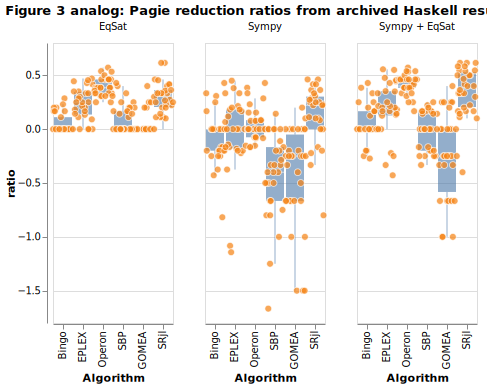

**What this shows:** For the archived Haskell Pagie rows, this is the target paper-era pattern: EqSat is helpful on its own, Sympy alone is weaker or can regress, and the combined pipeline recovers much of that gap. A faithful Egglog baseline should preserve that separation between the three modes.

In [4]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        y="ratio",
        title="Figure 3 analog: Pagie reduction ratios from archived Haskell results",
    )
)
show_note(
    summarize_haskell_reduction_ratios(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        context="the archived Haskell Pagie rows",
    )
)

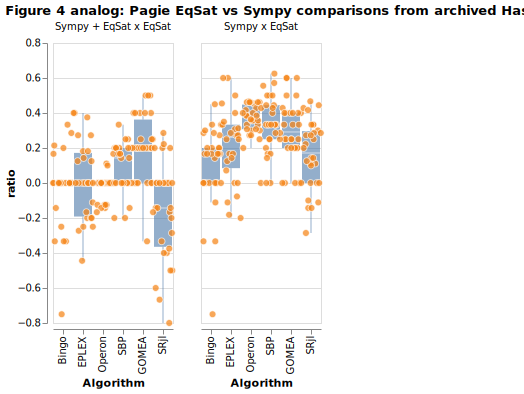

**What this shows:** For the archived Haskell Pagie comparisons, the archived baseline says EqSat is doing real extra work beyond Sympy preprocessing alone. That means a faithful Egglog reproduction should still show a visible advantage for rerunning EqSat after the symbolic preprocessing stage.

In [5]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        y="ratio",
        title="Figure 4 analog: Pagie EqSat vs Sympy comparisons from archived Haskell results",
    )
)
show_note(
    summarize_haskell_comparison_ratios(
        melt_methods(haskell[haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        context="the archived Haskell Pagie comparisons",
    )
)

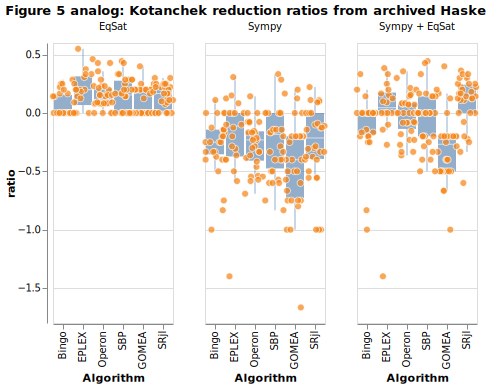

**What this shows:** For the archived Haskell Kotanchek rows, this is the target paper-era pattern: EqSat is helpful on its own, Sympy alone is weaker or can regress, and the combined pipeline recovers much of that gap. A faithful Egglog baseline should preserve that separation between the three modes.

In [6]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        y="ratio",
        title="Figure 5 analog: Kotanchek reduction ratios from archived Haskell results",
    )
)
show_note(
    summarize_haskell_reduction_ratios(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        context="the archived Haskell Kotanchek rows",
    )
)

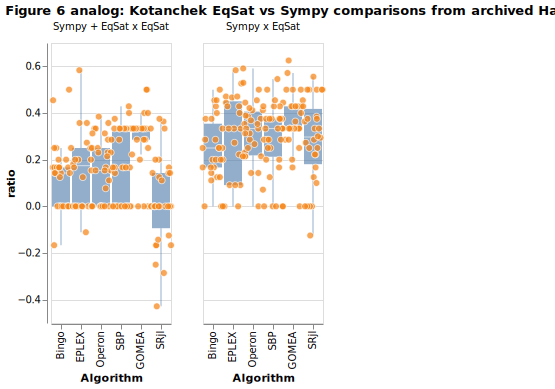

**What this shows:** For the archived Haskell Kotanchek comparisons, the archived baseline says EqSat is doing real extra work beyond Sympy preprocessing alone. That means a faithful Egglog reproduction should still show a visible advantage for rerunning EqSat after the symbolic preprocessing stage.

In [7]:
show_chart(
    boxplot_chart(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        y="ratio",
        title="Figure 6 analog: Kotanchek EqSat vs Sympy comparisons from archived Haskell results",
    )
)
show_note(
    summarize_haskell_comparison_ratios(
        melt_methods(haskell[haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        context="the archived Haskell Kotanchek comparisons",
    )
)

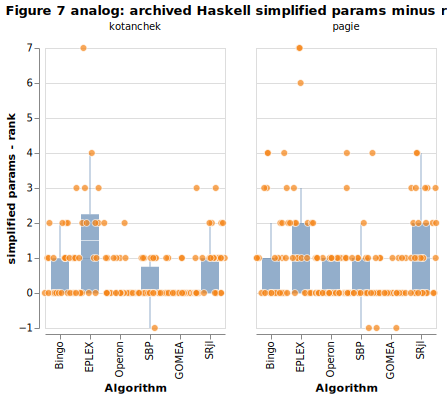

**What this shows:** For the archived Haskell runs, the archived baseline usually lands at or very near the target rank. So the reproduction target here is not just qualitative simplification, but getting most rows down to the rank target or within one.

In [8]:
show_chart(rank_boxplot(haskell, title="Figure 7 analog: archived Haskell simplified params minus rank"))
show_note(summarize_rank_target(haskell, context="the archived Haskell runs"))

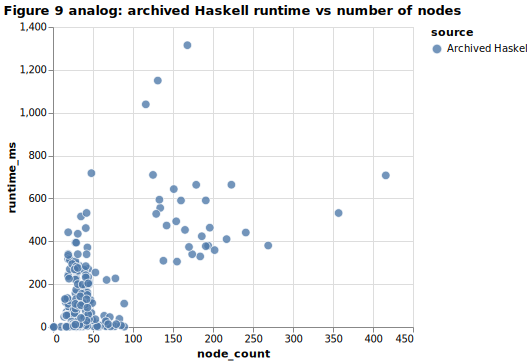

**What this shows:** For the archived Haskell runtime rows, the runtime tail clearly grows with expression size. This is the baseline difficulty pattern Egglog should match qualitatively even if exact runtimes differ.

In [9]:
show_chart(
    runtime_scatter(
        runtime_rows.assign(source="Archived Haskell"),
        x="node_count",
        y="runtime_ms",
        color="source",
        title="Figure 9 analog: archived Haskell runtime vs number of nodes",
    )
)
show_note(
    summarize_runtime_baseline(
        runtime_rows.assign(source="Archived Haskell"),
        x="node_count",
        y="runtime_ms",
        context="the archived Haskell runtime rows",
    )
)

In [10]:
display(Markdown("### Table 4 analog from archived Haskell results"))
display(table4_wide(haskell_table4, ["dataset", "algorithm"]).round(2))

### Table 4 analog from archived Haskell results

,dataset,algorithm,Δ == 0,Δ <= 1
0,kotanchek,Bingo,22.22,66.67
1,kotanchek,EPLEX,18.75,37.50
2,kotanchek,GP-GOMEA,NaN,NaN
3,kotanchek,Operon,74.07,94.44
4,kotanchek,PySR,NaN,NaN
5,kotanchek,SBP,65.22,100.00
6,pagie,Bingo,27.78,33.33
7,pagie,EPLEX,28.00,45.45
8,pagie,GP-GOMEA,NaN,NaN
9,pagie,Operon,66.67,100.00


In [11]:
display(
    Markdown(
        "### Figure 8 status\n\n"
        "The provided archives do not include the bulk Feynman/Operon result table "
        "needed to reproduce Figure 8 exactly, so this notebook marks that figure "
        "as unavailable rather than fabricating an approximation."
    )
)

### Figure 8 status

The provided archives do not include the bulk Feynman/Operon result table needed to reproduce Figure 8 exactly, so this notebook marks that figure as unavailable rather than fabricating an approximation.

## 3. Drift Between Published And Current Local Haskell

Before comparing Egglog to Haskell, it is useful to separate true Egglog
mismatches from drift between the published archived rows and the current
local `param-eq-haskell` implementation.

In [12]:
archive_drift_summary = pd.DataFrame(
    [
        {
            "comparison": "original expressions",
            "exact_param_matches": int((archive_drift["orig_param_drift"] == 0).sum()),
            "total_rows": len(archive_drift),
            "nonzero_drift_rows": int((archive_drift["orig_param_drift"] != 0).sum()),
        },
        {
            "comparison": "sympy expressions",
            "exact_param_matches": int((archive_drift["sympy_param_drift"] == 0).sum()),
            "total_rows": len(archive_drift),
            "nonzero_drift_rows": int((archive_drift["sympy_param_drift"] != 0).sum()),
        },
    ]
)
display(Markdown("### Published archived rows vs current local Haskell"))
display(archive_drift_summary)

### Published archived rows vs current local Haskell

,comparison,exact_param_matches,total_rows,nonzero_drift_rows
0,original expressions,320,341,21
1,sympy expressions,126,341,215


In [13]:
archive_drift_top = archive_drift.assign(abs_orig_drift=archive_drift["orig_param_drift"].abs())[
    [
        "dataset",
        "algorithm",
        "algo_row",
        "orig_param_drift",
        "sympy_param_drift",
        "simpl_params_live",
        "simpl_params_archived",
        "simpl_params_sympy_live",
        "simpl_params_sympy_archived",
    ]
].sort_values(["orig_param_drift"], key=lambda s: s.abs(), ascending=False)
display(Markdown("### Largest published-vs-live Haskell drifts"))
display(archive_drift_top.head(12))
display(Markdown("### Live-Haskell fallback rows"))
display(live_fallback_rows if not live_fallback_rows.empty else pd.DataFrame([{"status": "none"}]))
show_note(
    (
        f"The published and current local Haskell results already drift on "
        f"`{int((archive_drift['orig_param_drift'] != 0).sum())}` of `{len(archive_drift)}` original rows "
        f"and `{int((archive_drift['sympy_param_drift'] != 0).sum())}` of `{len(archive_drift)}` sympy rows. "
        f"The live artifact currently carries `{len(live_fallback_rows)}` archived fallback rows because those current local Haskell reruns still overflow their stack budget. "
        "So Egglog should now be judged primarily against the live Haskell artifact, while the archived rows remain important as the published-paper reference and as fallback for the pathological live rows."
    )
)

### Largest published-vs-live Haskell drifts

,dataset,algorithm,algo_row,orig_param_drift,sympy_param_drift,simpl_params_live,simpl_params_archived,simpl_params_sympy_live,simpl_params_sympy_archived
19,pagie,Bingo,21,-3.0,0.0,4.0,7.0,4.0,4.0
49,pagie,EPLEX,25,-3.0,-9.0,7.0,10.0,7.0,16.0
3,pagie,Bingo,4,-2.0,0.0,6.0,8.0,6.0,6.0
25,pagie,Bingo,27,-2.0,-5.0,9.0,11.0,9.0,14.0
44,pagie,EPLEX,20,-2.0,-2.0,9.0,11.0,9.0,11.0
30,pagie,EPLEX,5,-2.0,-2.0,11.0,13.0,11.0,13.0
203,kotanchek,EPLEX,4,-2.0,-2.0,8.0,10.0,8.0,10.0
201,kotanchek,EPLEX,1,-1.0,-2.0,8.0,9.0,9.0,11.0
22,pagie,Bingo,24,-1.0,-1.0,4.0,5.0,4.0,5.0
23,pagie,Bingo,25,-1.0,0.0,3.0,4.0,3.0,3.0


### Live-Haskell fallback rows

,dataset,algorithm,algo_row,baseline_source,orig_live_status,sympy_live_status
161,pagie,SRjl,18,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow
191,kotanchek,Bingo,21,archived_fallback,archived_fallback_stack_overflow,archived_fallback_stack_overflow


**What this shows:** The published and current local Haskell results already drift on `21` of `341` original rows and `215` of `341` sympy rows. The live artifact currently carries `2` archived fallback rows because those current local Haskell reruns still overflow their stack budget. So Egglog should now be judged primarily against the live Haskell artifact, while the archived rows remain important as the published-paper reference and as fallback for the pathological live rows.

## 4. Egglog Translation of the Older Hegg-Era Pipeline

The Egglog runner uses the archived experiment harness as the baseline:
- the older expression language from the paper-era code
- the paper-era extraction cost model
- the `FixTree.hs` rewrite loop and backoff scheduler

In [14]:
baseline_summary = [
    f"- Egglog baseline original-input status counts: `{egglog_baseline['orig_status'].value_counts().to_dict()}`",
    f"- Egglog baseline sympy-input status counts: `{egglog_baseline['sympy_status'].value_counts().to_dict()}`",
]
display(Markdown("## Egglog Run Overview\n\n" + "\n".join(baseline_summary)))

## Egglog Run Overview

- Egglog baseline original-input status counts: `{'saturated': 341}`
- Egglog baseline sympy-input status counts: `{'saturated': 341}`

## 5. Current Local Haskell vs Egglog Comparison

The next figures compare Egglog to the current local Haskell corpus artifact.
For the Egglog charts, "Sympy" means the archived Sympy output re-counted by
the Egglog parser, and "Sympy + EqSat" means running the Egglog EqSat
translation on the archived Sympy expression.

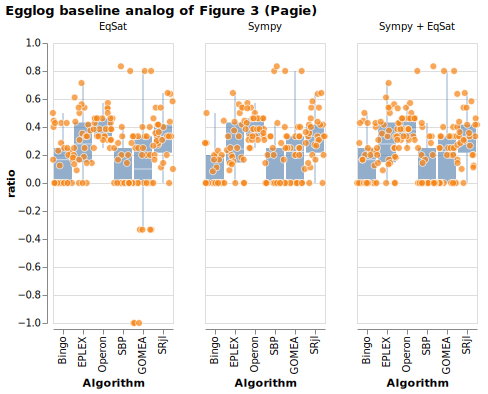

**What this shows:** For the Egglog baseline Pagie rows against current local Haskell, Egglog broadly preserves the same qualitative ordering as the Haskell reference artifact, which supports the hypothesis that the reproduction is close on this slice.

In [15]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 3 (Pagie)",
    )
)
show_note(
    summarize_egglog_reduction_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        melt_methods(live_haskell[live_haskell["dataset"] == "pagie"], columns=haskell_box_methods, value_name="ratio"),
        context="the Egglog baseline Pagie rows against current local Haskell",
    )
)

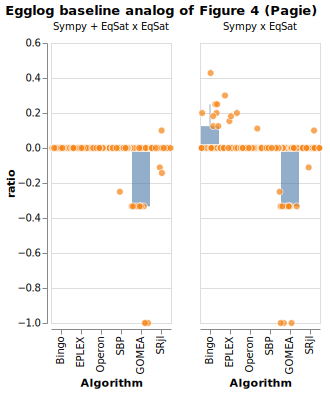

**What this shows:** For the Egglog baseline Pagie comparisons against current local Haskell, Egglog retains most of the Haskell-reference advantage of EqSat over the Sympy-derived inputs, which supports the baseline-reproduction hypothesis for this comparison.

In [16]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 4 (Pagie)",
    )
)
show_note(
    summarize_egglog_comparison_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        melt_methods(live_haskell[live_haskell["dataset"] == "pagie"], columns=comparison_methods, value_name="ratio"),
        context="the Egglog baseline Pagie comparisons against current local Haskell",
    )
)

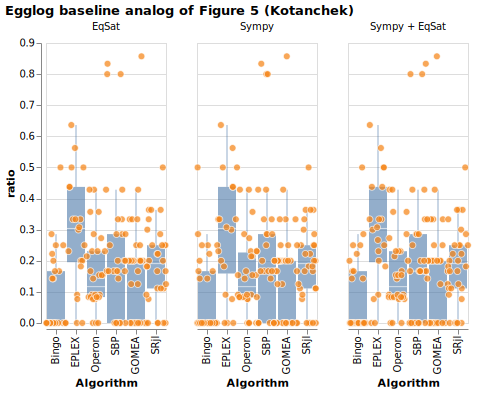

**What this shows:** For the Egglog baseline Kotanchek rows against current local Haskell, Egglog broadly preserves the same qualitative ordering as the Haskell reference artifact, which supports the hypothesis that the reproduction is close on this slice.

In [17]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 5 (Kotanchek)",
    )
)
show_note(
    summarize_egglog_reduction_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        melt_methods(live_haskell[live_haskell["dataset"] == "kotanchek"], columns=haskell_box_methods, value_name="ratio"),
        context="the Egglog baseline Kotanchek rows against current local Haskell",
    )
)

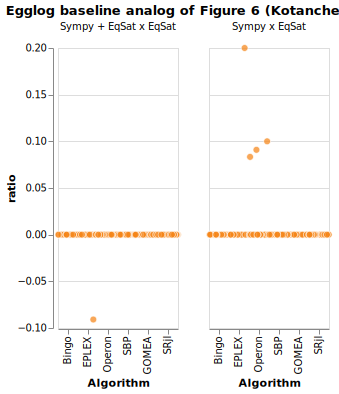

**What this shows:** For the Egglog baseline Kotanchek comparisons against current local Haskell, Egglog retains most of the Haskell-reference advantage of EqSat over the Sympy-derived inputs, which supports the baseline-reproduction hypothesis for this comparison.

In [18]:
show_chart(
    boxplot_chart(
        melt_methods(
            egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"
        ),
        y="ratio",
        title="Egglog baseline analog of Figure 6 (Kotanchek)",
    )
)
show_note(
    summarize_egglog_comparison_vs_haskell(
        melt_methods(egglog_baseline[egglog_baseline["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        melt_methods(live_haskell[live_haskell["dataset"] == "kotanchek"], columns=comparison_methods, value_name="ratio"),
        context="the Egglog baseline Kotanchek comparisons against current local Haskell",
    )
)

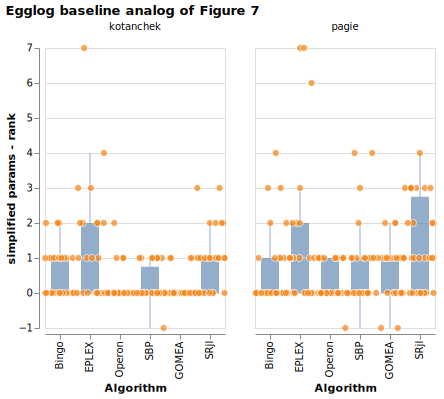

**What this shows:** For the Egglog baseline runs against current local Haskell, Egglog is close to the Haskell reference on the coarse rank target. So the remaining mismatch is not that Egglog fails to simplify at all; it is that it still misses some of the exact final forms and some hard cases.

In [19]:
show_chart(rank_boxplot(egglog_baseline, title="Egglog baseline analog of Figure 7"))
show_note(
    summarize_egglog_rank_vs_haskell(
        egglog_baseline,
        live_haskell,
        context="the Egglog baseline runs against current local Haskell",
    )
)

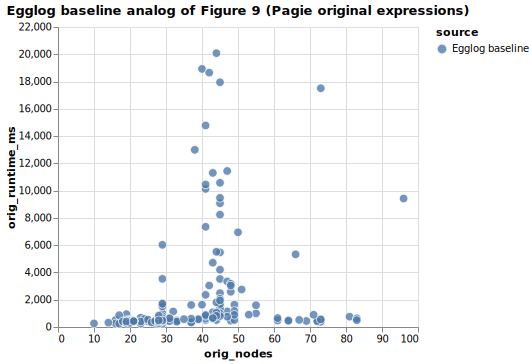

**What this shows:** For the Egglog baseline Pagie originals, runtime does not track size as strongly as in the Haskell reference, which would suggest a different failure mode.

In [20]:
show_chart(
    runtime_scatter(
        egglog_baseline[egglog_baseline["dataset"] == "pagie"].assign(source="Egglog baseline"),
        x="orig_nodes",
        y="orig_runtime_ms",
        color="source",
        title="Egglog baseline analog of Figure 9 (Pagie original expressions)",
    )
)
show_note(
    summarize_egglog_runtime(
        egglog_baseline[egglog_baseline["dataset"] == "pagie"].assign(source="Egglog baseline"),
        x="orig_nodes",
        y="orig_runtime_ms",
        context="the Egglog baseline Pagie originals",
    )
)

In [21]:
display(Markdown("### Table 4 analogs for Egglog"))
display(table4_wide(egglog_table4, ["implementation", "dataset", "algorithm"]).round(2))

### Table 4 analogs for Egglog

,implementation,dataset,algorithm,Δ == 0,Δ <= 1
0,Egglog baseline,kotanchek,Bingo,22.22,66.67
1,Egglog baseline,kotanchek,EPLEX,18.75,43.75
2,Egglog baseline,kotanchek,GP-GOMEA,NaN,NaN
3,Egglog baseline,kotanchek,Operon,85.19,94.44
4,Egglog baseline,kotanchek,PySR,NaN,NaN
5,Egglog baseline,kotanchek,SBP,65.22,100.00
6,Egglog baseline,pagie,Bingo,55.56,66.67
7,Egglog baseline,pagie,EPLEX,40.00,63.64
8,Egglog baseline,pagie,GP-GOMEA,NaN,NaN
9,Egglog baseline,pagie,Operon,70.00,100.00


In [22]:
exact_match_rows = pd.DataFrame([
    {
        "mode": "Egglog baseline",
        "input": "original expressions",
        "exact_param_matches": int(baseline_compare["orig_param_match"].sum()),
        "total_rows": len(baseline_compare),
    },
    {
        "mode": "Egglog baseline",
        "input": "sympy expressions",
        "exact_param_matches": int(baseline_compare["sympy_param_match"].sum()),
        "total_rows": len(baseline_compare),
    },
])
display(Markdown("### Exact-match counts against current local Haskell parameter totals"))
display(exact_match_rows)

### Exact-match counts against current local Haskell parameter totals

,mode,input,exact_param_matches,total_rows
0,Egglog baseline,original expressions,318,341
1,Egglog baseline,sympy expressions,336,341


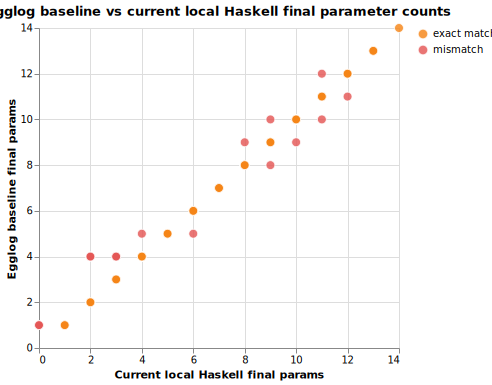

**What this shows:** For saturated original-expression rows, most sit on or very near the diagonal. That supports the hypothesis that Egglog is partially reproducing the Haskell reference on final parameter counts, but not yet meeting it exactly across the whole corpus.

In [23]:
baseline_orig_scatter = baseline_compare[baseline_compare["orig_status"] == "saturated"].copy()
baseline_orig_scatter["match"] = baseline_orig_scatter["orig_param_match"].map({True: "exact match", False: "mismatch"})
show_chart(
    alt.Chart(baseline_orig_scatter)
    .mark_circle(size=78, opacity=0.82, stroke="white", strokeWidth=0.85)
    .encode(
        x=alt.X("simpl_params_haskell:Q", title="Current local Haskell final params"),
        y=alt.Y("simpl_params_egglog:Q", title="Egglog baseline final params"),
        color=alt.Color(
            "match:N",
            title=None,
            scale=alt.Scale(domain=["exact match", "mismatch"], range=[POINT_COLOR, MISMATCH_COLOR]),
        ),
        tooltip=["dataset", "algorithm", "algo_row", "simpl_params_haskell", "simpl_params_egglog", "orig_rendered"],
    )
    .properties(title="Egglog baseline vs current local Haskell final parameter counts", width=360, height=320)
)
show_note(summarize_match_scatter(baseline_orig_scatter, context="saturated original-expression rows"))

In [24]:
baseline_summary_frame = pd.DataFrame([
    {
        "mode": "Egglog baseline",
        "orig_non_saturated_rows": int((egglog_baseline["orig_status"] != "saturated").sum()),
        "sympy_non_saturated_rows": int((egglog_baseline["sympy_status"] != "saturated").sum()),
        "median_orig_runtime_ms": float(egglog_baseline["orig_runtime_ms"].median()),
        "median_sympy_runtime_ms": float(egglog_baseline["sympy_runtime_ms"].median()),
    },
])
display(Markdown("### Egglog baseline summary"))
display(baseline_summary_frame.round(2))

### Egglog baseline summary

,mode,orig_non_saturated_rows,sympy_non_saturated_rows,median_orig_runtime_ms,median_sympy_runtime_ms
0,Egglog baseline,0,0,655.77,408.68


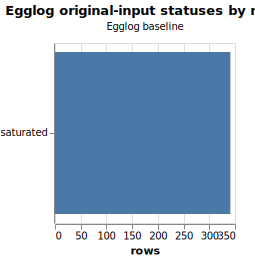

**What this shows:** For Egglog original-input runs, nearly all finish in the normal saturated path. That means the current baseline is usable for comparison work, but the remaining unsaturated tail is still large enough to matter for paper-faithful reproduction.

In [25]:
show_chart(
    status_summary_chart(
        status_rows.groupby(["mode", "status"]).size().reset_index(name="count"),
        title="Egglog original-input statuses by mode",
    )
)
show_note(
    summarize_status_counts(
        status_rows.groupby(["mode", "status"]).size().reset_index(name="count"),
        context="Egglog original-input runs",
    )
)

In [26]:
display(
    Markdown(
        "\n".join([
            "## Comparison Summary",
            "",
            f"- Egglog baseline exactly matches current local Haskell final parameter counts on `{int(baseline_compare['orig_param_match'].sum())}` of `{len(baseline_compare)}` original-expression rows.",
            f"- Egglog baseline exactly matches current local Haskell `Sympy + EqSat` parameter counts on `{int(baseline_compare['sympy_param_match'].sum())}` of `{len(baseline_compare)}` sympy-expression rows.",
            f"- Egglog baseline original-input timeouts or failures occur on `{int((egglog_baseline['orig_status'] != 'saturated').sum())}` of `{len(egglog_baseline)}` paper rows.",
            f"- Egglog baseline sympy-input timeouts or failures occur on `{int((egglog_baseline['sympy_status'] != 'saturated').sum())}` of `{len(egglog_baseline)}` paper rows.",
        ])
    )
)

## Comparison Summary

- Egglog baseline exactly matches current local Haskell final parameter counts on `318` of `341` original-expression rows.
- Egglog baseline exactly matches current local Haskell `Sympy + EqSat` parameter counts on `336` of `341` sympy-expression rows.
- Egglog baseline original-input timeouts or failures occur on `0` of `341` paper rows.
- Egglog baseline sympy-input timeouts or failures occur on `0` of `341` paper rows.

## 6. Scheduler Ablation

These rows remove one scheduler customization at a time while keeping the
Haskell rewrite set and explicit analysis structure fixed.

In [27]:
display(Markdown("### Scheduler ablation acceptance table"))
if ablation_summary.empty:
    display(pd.DataFrame([{"status": "no ablation artifact available"}]))
else:
    display(ablation_summary)
show_note(summarize_ablation_results(ablation_summary))

### Scheduler ablation acceptance table

,mode,evaluation_scope,orig_exact,sympy_exact,orig_saturated,sympy_saturated,orig_max_gap,sympy_max_gap,orig_median_delta,sympy_median_delta,orig_pattern_ok,sympy_pattern_ok,accepted,note
0,Egglog baseline,full corpus,318/341,336/341,341/341,341/341,2.0,1.0,-1.0,-1.0,False,False,False,Retained baseline against current local Haskell.
1,No Haskell backoff,targeted fail,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,Timed out on `pagie Operon#15` original while ...
2,No graph-size stop,targeted parity only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,Matched the targeted `pagie Operon#15` and `pa...
3,No bound scheduler,full corpus,315/341,336/341,339/341,341/341,2.0,1.0,-1.0,-1.0,True,True,False,Loses full original-input saturation by timing...
4,No fresh rematch,full corpus,317/341,336/341,339/341,341/341,2.0,1.0,-1.0,-1.0,True,True,False,Loses full original-input saturation by timing...


**What this shows:** More than one mode preserves the live-Haskell notebook conclusions. The currently acceptable stack(s) are: . Prefer the simplest surviving one.

## 7. Current Limitations

The statements below are derived from the loaded artifacts, using current
local Haskell as the primary comparison target and the archived paper rows as
the published-reference target.

In [28]:
orig_mismatches = baseline_compare[~baseline_compare["orig_param_match"]].copy()
sympy_mismatches = baseline_compare[~baseline_compare["sympy_param_match"]].copy()
orig_by_algorithm = orig_mismatches.groupby(["dataset", "algorithm"]).size().sort_values(ascending=False)
sympy_by_algorithm = sympy_mismatches.groupby(["dataset", "algorithm"]).size().sort_values(ascending=False)
orig_max_gap = float(baseline_compare["orig_abs_gap"].max())
sympy_max_gap = float(
    (
        baseline_compare["simpl_params_sympy_egglog"] - baseline_compare["simpl_params_sympy_haskell"]
    )
    .abs()
    .max()
)
archive_orig_drift = int((archive_drift["orig_param_drift"] != 0).sum())
archive_sympy_drift = int((archive_drift["sympy_param_drift"] != 0).sum())
accepted_ablation_modes = (
    ", ".join(ablation_summary.loc[ablation_summary["accepted"], "mode"].tolist()) if not ablation_summary.empty else "unavailable"
)

conclusion_lines = [
    f"- The Egglog baseline now saturates on all `{len(egglog_baseline)}` retained paper rows for both original and sympy inputs.",
    f"- Against the current local Haskell artifact, Egglog exactly matches final parameter counts on `{int(baseline_compare['orig_param_match'].sum())}` of `{len(baseline_compare)}` original rows and `{int(baseline_compare['sympy_param_match'].sum())}` of `{len(baseline_compare)}` sympy rows.",
    f"- The live Haskell artifact currently includes `{len(live_fallback_rows)}` archived fallback rows for cases that still overflow the current local Haskell stack budget.",
    f"- The remaining original-input gaps are small: the largest current live-Haskell gap is `{orig_max_gap:.0f}` parameters.",
    f"- The remaining sympy-input gaps are also small: the largest current live-Haskell gap is `{sympy_max_gap:.0f}` parameter.",
    f"- The published archived rows drift from current local Haskell on `{archive_orig_drift}` original rows and `{archive_sympy_drift}` sympy rows, so not every paper-row mismatch should be treated as an Egglog bug.",
    f"- Original-input live mismatches are currently concentrated in `{', '.join(f'{dataset} {alg} ({count})' for (dataset, alg), count in orig_by_algorithm.head(6).items()) or 'none'}`.",
    f"- Sympy-input live mismatches are currently concentrated in `{', '.join(f'{dataset} {alg} ({count})' for (dataset, alg), count in sympy_by_algorithm.head(6).items()) or 'none'}`.",
    f"- Scheduler ablation modes that still preserve the current notebook-level live-Haskell conclusions: `{accepted_ablation_modes}`.",
    "",
    "The practical next step is now narrower than before:",
    "- if only the retained baseline survives the ablation gate, keep the current scheduler stack and return to the small live-mismatch tail",
    "- if a simpler ablation survives, prefer that simpler stack and then regenerate the live comparison notebook from it",
    "- either way, classify the two live-Haskell fallback rows separately from true Egglog mismatches",
]
display(Markdown("## Conclusion\n\n" + "\n".join(conclusion_lines)))

## Conclusion

- The Egglog baseline now saturates on all `341` retained paper rows for both original and sympy inputs.
- Against the current local Haskell artifact, Egglog exactly matches final parameter counts on `318` of `341` original rows and `336` of `341` sympy rows.
- The live Haskell artifact currently includes `2` archived fallback rows for cases that still overflow the current local Haskell stack budget.
- The remaining original-input gaps are small: the largest current live-Haskell gap is `2` parameters.
- The remaining sympy-input gaps are also small: the largest current live-Haskell gap is `1` parameter.
- The published archived rows drift from current local Haskell on `21` original rows and `215` sympy rows, so not every paper-row mismatch should be treated as an Egglog bug.
- Original-input live mismatches are currently concentrated in `pagie GOMEA (10), kotanchek Operon (3), pagie SBP (3), kotanchek EPLEX (2), kotanchek SBP (2), pagie SRjl (2)`.
- Sympy-input live mismatches are currently concentrated in `kotanchek Operon (3), pagie Operon (1), pagie SRjl (1)`.
- Scheduler ablation modes that still preserve the current notebook-level live-Haskell conclusions: ``.

The practical next step is now narrower than before:
- if only the retained baseline survives the ablation gate, keep the current scheduler stack and return to the small live-mismatch tail
- if a simpler ablation survives, prefer that simpler stack and then regenerate the live comparison notebook from it
- either way, classify the two live-Haskell fallback rows separately from true Egglog mismatches

In [29]:
def _write_executed_notebook() -> None:
    source_path = PARAM_EQ_DIR / "replication.py"
    output_path = source_path.with_suffix(".ipynb")
    notebook = jupytext.read(source_path, fmt="py:light")
    previous = os.environ.get("EGGLOG_PARAM_EQ_SYNC_IPYNB")
    os.environ["EGGLOG_PARAM_EQ_SYNC_IPYNB"] = "0"
    try:
        executed = NotebookClient(notebook, timeout=600, kernel_name="python3").execute()
    finally:
        if previous is None:
            os.environ.pop("EGGLOG_PARAM_EQ_SYNC_IPYNB", None)
        else:
            os.environ["EGGLOG_PARAM_EQ_SYNC_IPYNB"] = previous
    with output_path.open("w", encoding="utf-8") as handle:
        nbformat.write(executed, handle)

In [30]:
if __name__ == "__main__" and os.environ.get("EGGLOG_PARAM_EQ_SYNC_IPYNB", "1") != "0":
    _write_executed_notebook()